This is my code to train my own ML model to recognize my image data that I took from our lab microscope. I realized the need to train our own model, when other particle detection software was not working on our images. We use our ML model to recognize single molecule detection events in our data, which we subsequently gather all the statistics for using the OpenCV library. At the end, I include some histogram visualizations of our image data in different ways.

Import all necessary libraries

In [18]:
import os
import tifffile as tiff
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from fastcore.all import *
from fastai.vision.all import *
import torch
import torch.nn.functional as F
from fastai.vision.core import PILImageBW

from pathlib import Path
import imageio.v2 as imageio


from torch.utils.data import Subset
from torch.utils.data import TensorDataset

This is just a GPU availability check!

In [19]:
# Pick the best device available (CUDA for NVIDIA/ROCm, MPS for Apple)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Device:", device)
if device.type == 'cuda':
    print("GPU name:", torch.cuda.get_device_name(0))


Device: cpu


Next, I upload the data files that I want to use to train my image recognition ML model. The input to the model will be images of data that I have collected. I want to highlight regions of the image that may pertain to single molecule detection, so the output file for each image will be a binary map of pixel value 0 -- no single molecule, or 1 -- single molecule detected.

In [3]:
yes_stack = tiff.imread("/mnt/c/Users/inkil/Documents/ML data/training data from 04/final/yes input.tif")      # shape: [N, H, W]
yes_masks = tiff.imread("/mnt/c/Users/inkil/Documents/ML data/training data from 04/final/yes output.tif")
no_stack = tiff.imread("/mnt/c/Users/inkil/Documents/ML data/training data from 04/final/no input.tif")
no_masks = tiff.imread("/mnt/c/Users/inkil/Documents/ML data/training data from 04/final/no output.tif")

Below, we change the shape of our data to load it into DataLoader batches that we can input into our ML model. We also split our data into training and validation datasets.

In [4]:
X = torch.cat([
    torch.tensor(yes_stack, dtype=torch.float32),
    torch.tensor(no_stack, dtype=torch.float32)
], dim=0)  # shape: [N, H, W]

Y = torch.cat([
    torch.tensor(yes_masks, dtype=torch.long),
    torch.tensor(no_masks, dtype=torch.long)
], dim=0)  # shape: [N, H, W]

# Add channel dim to X
X = X.unsqueeze(1)  # shape: [N, 1, H, W]
#Y = Y.unsqueeze(1)

In [5]:
from sklearn.model_selection import train_test_split

idxs = list(range(len(X)))
train_idxs, valid_idxs = train_test_split(idxs, test_size=0.2, random_state=42)

In [6]:
ds = TensorDataset(X, Y)
train_ds = Subset(ds, train_idxs)
valid_ds = Subset(ds, valid_idxs)

In [7]:
train_dl = DataLoader(train_ds, batch_size=8, shuffle=True)
valid_dl = DataLoader(valid_ds, batch_size=8)

dls = DataLoaders(train_dl, valid_dl).cuda()

Just for visualization of each batch of data, here is an example of a frame that contains a possible single particle detection event, and the corresponding mask that shows where the particle is located. Each mask was engineered manually. We want to train our ML model to associate signals like the ones we see in our input image to be regions of the image that we are interested in.

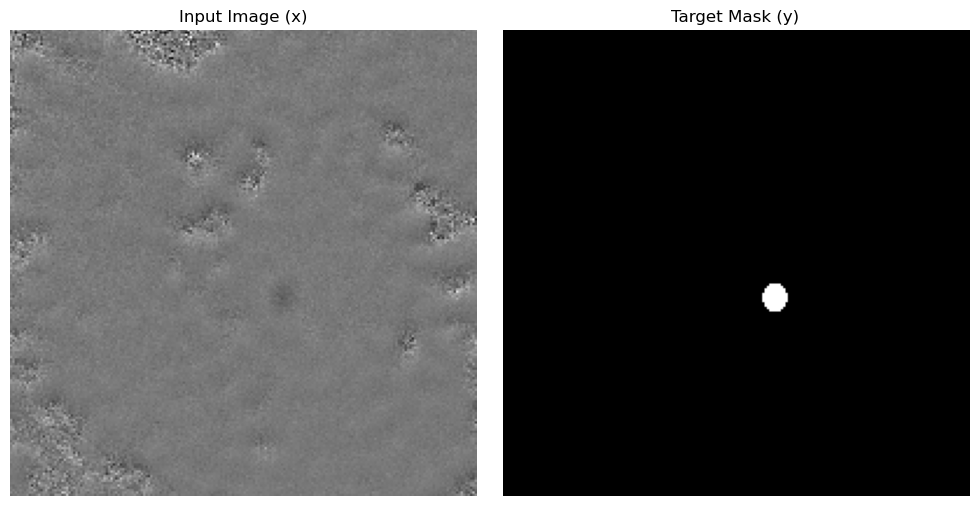

In [17]:
xb, yb = dls.one_batch()  # get a batch
img = xb[0][0].cpu()       # shape: [H, W] for grayscale
mask = yb[0].cpu()         # shape: [H, W]

# Plot input image and mask side by side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Input Image (x)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("Target Mask (y)")
plt.axis('off')

plt.tight_layout()
plt.show()

We train our model with cross entropy loss function, common for image recognition models. We assign our model to be evaluated using a Dice coefficient (F1 score), since we are interested in how similar our model's maps are to the "ground truth" maps that we have prepared ourselves. This method is common in image segmentation techniques.

In [15]:
learn = unet_learner(
    dls,
    resnet18,
    n_in=1,  # grayscale input
    n_out=2,             # number of classes in mask
    loss_func=nn.CrossEntropyLoss(),
    metrics=Dice()
)

#learn.fine_tune(20)

In [40]:
learn.fine_tune(20)

epoch,train_loss,valid_loss,dice,time
0,0.014002,0.001211,0.000000,01:58


epoch,train_loss,valid_loss,dice,time
0,0.000862,0.000615,0.530586,02:03
1,0.000503,0.000510,0.531161,02:05
2,0.000476,0.000567,0.564604,02:06
3,0.000425,0.000405,0.680216,02:06
4,0.000807,0.000687,0.466338,02:05
5,0.000332,0.000782,0.410845,02:06
6,0.000281,0.000598,0.580584,02:08
7,0.000180,0.000470,0.671583,02:07
8,0.000295,0.000524,0.604471,02:08
9,0.000135,0.000782,0.650814,02:08


Looking through the model's output maps, I believe this is a sufficient Dice score to move on. I would be a lot more strict about achieving a higher Dice score, if I didn't know that my "ground truth" maps are also subject to human error, since I engineered them myself.

In [41]:
learn.save('/mnt/c/Users/inkil/Documents/ML data/training data from 04/cleaner iSCAT p3')

Path('/mnt/c/Users/inkil/Documents/ML data/training data from 04/cleaner iSCAT p3.pth')

For future data analysis, I load the saved model.

In [9]:
#learn.save('stage-1')
learn = learn.load('/mnt/c/Users/inkil/Documents/ML data/training data from 04/cleaner iSCAT p3', weights_only=False)

In [10]:
del yes_stack, yes_masks, no_stack, no_masks

In [11]:
del X, Y

Here, I define a function to get stats from OpenCV's image processing library. This is to get the pixel statistics stats of my particles!

In [12]:
import cv2


def components_table_from_labels(frame_np: np.ndarray,
                                 labels: np.ndarray,
                                 stats: np.ndarray,
                                 centroids: np.ndarray,
                                 frame_index: int,
                                 min_area: int = 0) -> pd.DataFrame:
    """
    Build a per-component table with (frame, x, y, area, mean_intensity, max_contrast_pixel)
    using OpenCV outputs only. Background (label 0) is excluded.
    
    max_contrast_pixel = the actual pixel value that has the maximum absolute deviation 
                         from the component's mean intensity
    """
    # stats: rows 0..K with 0=background; columns include AREA
    areas = stats[:, cv2.CC_STAT_AREA]  # length K+1 (0=bg)
    if len(areas) <= 1:
        return pd.DataFrame(columns=["frame", "x", "y", "area", "mean_intensity", "max_contrast_pixel"])
    
    # Sum intensities per label with a single pass (fast)
    # minlength ensures we have an entry for every label id (0..K)
    sums = np.bincount(
        labels.ravel(),
        weights=frame_np.ravel().astype(np.float64, copy=False),
        minlength=areas.shape[0]
    )
    
    # Drop background
    areas_fg = areas[1:]
    sums_fg  = sums[1:]
    cent_fg  = centroids[1:]   # shape (K, 2) in (x,y)
    
    # Optional area filter
    if min_area > 0:
        keep_mask = areas_fg >= min_area
        if not np.any(keep_mask):
            return pd.DataFrame(columns=["frame", "x", "y", "area", "mean_intensity", "max_contrast_pixel"])
        areas_fg = areas_fg[keep_mask]
        sums_fg  = sums_fg[keep_mask]
        cent_fg  = cent_fg[keep_mask]
    
    # Mean intensity per component
    mean_int = sums_fg / areas_fg
    
    # --- NEW: Calculate pixel value with max absolute contrast for each component ---
    # We need to iterate through each label to find the pixel furthest from mean
    num_components = len(areas_fg)
    max_contrast_pixels = np.zeros(num_components, dtype=np.float32)
    
    # Get the label IDs that survived filtering
    if min_area > 0:
        keep_mask = areas[1:] >= min_area
        label_ids = np.where(keep_mask)[0] + 1  # +1 because we dropped background
    else:
        label_ids = np.arange(1, len(areas))
    
    # For each component, find the pixel value with max absolute deviation from mean
    for idx, label_id in enumerate(label_ids):
        # Get mask for this component
        component_mask = (labels == label_id)
        
        # Get pixel values for this component
        component_pixels = frame_np[component_mask]
        
        # Find the pixel value that is furthest from the mean
        abs_deviations = np.abs(component_pixels - mean_int[idx])
        max_deviation_idx = abs_deviations.argmax()
        max_contrast_pixels[idx] = component_pixels[max_deviation_idx]
    
    # centroids are (x, y); build table
    df = pd.DataFrame({
        "frame": np.full(areas_fg.shape[0], frame_index, dtype=np.int64),
        "x": cent_fg[:, 0],
        "y": cent_fg[:, 1],
        "area": areas_fg.astype(np.int64, copy=False),
        "mean_intensity": mean_int.astype(np.float32, copy=False),
        "max_contrast_pixel": max_contrast_pixels,
    })
    return df

Below, I input my image data that I want to process. We can combine our two workflows: 
First, we ask our ML model to create an output binary particle detection map from the input images that we are interested in. If we want a probability map, we can ask our model for it (it converts logits to probability based on a sigmoid function). But that can take up a lot of storage space, to save a probability map. Most of the time, I ask my model for a binary map where every pixel is 1 or 0 based on a threshold probability value, which I can set myself. I avoid softmax code and directly assign the sigmoid function myself, since softmax can be more computationally intensive and we do not need it in this case, since this is only a binary classification.

Second, we ask our code to go back and collect the particle stats in time, area, mean intensity, and location based on the particles that the ML model has detected. We save the statistical data in a parquet, which we later store in a Pandas dataframe.

In [13]:
from contextlib import nullcontext
from tqdm import tqdm

import pyarrow as pa
import pyarrow.parquet as pq

# ------------- CONFIG -------------
path_in   = "/mnt/c/Users/inkil/Documents/07 IL worked up/exp09 water/end avg5 group1.tif"
out_prob  = None                           # set to "signal_probability_heatmaps.tiff" only if truly needed
out_mask  = "/mnt/c/Users/inkil/Documents/07 IL worked up/exp09 water/end binary_signal_masks updated model.tif"
out_lbl   = None                           # e.g., "labeled_components.tiff" if desired
parquet_path = "particles.parquet"

threshold_p = 0.9
LOGIT_T = float(np.log(threshold_p/(1-threshold_p)))  # ~2.197 for 0.9
BATCH     = 64                         # increase until VRAM ~80–90%
CONNECTIVITY = 8                       # 4 or 8 (OpenCV)
MIN_AREA  = 0                          # drop tiny blobs if >0
WRITE_COMPRESSION = None               # None or ("zlib", 1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ✅ Notice at start of run
if device.type == 'cuda':
    print(f"Using CUDA (GPU): {torch.cuda.get_device_name(0)}")
else:
    print("Using CPU only")

    
model = learn.model.eval().to(device)

# Perf toggles (GPU)
torch.backends.cudnn.benchmark = True
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

# Prefer channels_last if your model is conv-heavy
model = model.to(memory_format=torch.channels_last)

def _tiff_write_page(writer, arr):
    if WRITE_COMPRESSION:
        comp, level = WRITE_COMPRESSION
        writer.write(arr, compression=comp, compresslevel=level, photometric='minisblack')
    else:
        writer.write(arr, photometric='minisblack')

# Clean old parquet if present
if os.path.exists(parquet_path):
    os.remove(parquet_path)
writer = None  # ParquetWriter

# ------------- RUN -------------
with tiff.TiffFile(path_in) as tf, \
     (tiff.TiffWriter(out_prob, bigtiff=True) if out_prob else nullcontext()) as prob_w, \
     (tiff.TiffWriter(out_mask, bigtiff=True) if out_mask else nullcontext()) as mask_w, \
     (tiff.TiffWriter(out_lbl,  bigtiff=True) if out_lbl  else nullcontext()) as lbl_w:

    n = len(tf.pages)
    SKIP = 14053
    for i0 in tqdm(range(SKIP, n, BATCH), desc="Processing frames", unit="frame"):
        i1 = min(i0 + BATCH, n)

        # --- Read batch (CPU) ---
        frames = [tf.pages[i].asarray() for i in range(i0, i1)]  # list of [H,W]

        # --- Build input [B,1,H,W] -> channels_last -> device ---
        xb = torch.stack([torch.from_numpy(fr) for fr in frames]).unsqueeze(1)
        xb = xb.to(memory_format=torch.channels_last).to(device, non_blocking=True)

        # Normalize on GPU
        if xb.dtype == torch.uint16:
            xb = xb.float().div_(65535.0)
        elif xb.dtype == torch.uint8:
            xb = xb.float().div_(255.0)
        else:
            xb = xb.float()

        #Inference (fast eval path)
        with torch.inference_mode(), torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
            logits = model(xb)  # [B,C,H,W]

        #Binary mask WITHOUT softmax
        if logits.shape[1] >= 2:
            logit_diff = logits[:, 1] - logits[:, 0]
            masks = (logit_diff > LOGIT_T)
        else:
            masks = (torch.sigmoid(logits[:, 0]) > threshold_p)

        # Optional probabilities (off by default)
        if out_prob:
            probs = torch.sigmoid(logit_diff if logits.shape[1] >= 2 else logits[:,0])
            probs_cpu = probs.float().cpu().numpy()

        masks_cpu = masks.to(torch.uint8).cpu().numpy()  # [B,H,W], 0/1

        #Write outputs (optional)
        if out_prob:
            for k in range(probs_cpu.shape[0]):
                _tiff_write_page(prob_w, probs_cpu[k].astype(np.float32))
        if out_mask:
            for k in range(masks_cpu.shape[0]):
                _tiff_write_page(mask_w, masks_cpu[k].astype(np.uint8))

        # --- Label + stats via OpenCV + bincount (no skimage) ---
        batch_tables = []
        for k, (frame_np, mask_np) in enumerate(zip(frames, masks_cpu)):
            # Ensure binary 0/255 for OpenCV (robustness)
            bin8 = (mask_np > 0).astype(np.uint8) * 255

            num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
                bin8, connectivity=CONNECTIVITY
            )
            # Optionally save labels
            if out_lbl:
                _tiff_write_page(lbl_w, labels.astype(np.int32))

            if num_labels <= 1:
                continue  # no components

            # Compute table quickly (area, centroid, mean_intensity)
            df = components_table_from_labels(
                frame_np=frame_np,
                labels=labels,
                stats=stats,
                centroids=centroids,
                frame_index=i0 + k,
                min_area=MIN_AREA
            )
            if not df.empty:
                batch_tables.append(df)

        # --- Write a Parquet row group only if we found blobs ---
        if batch_tables:
            df_batch = pd.concat(batch_tables, ignore_index=True)
            table = pa.Table.from_pandas(df_batch, preserve_index=False)
            if writer is None:
                writer = pq.ParquetWriter(parquet_path, table.schema, compression="zstd")
            writer.write_table(table)

if writer is not None:
    writer.close()


print("Done. Particles →", parquet_path, "| Masks →", out_mask if out_mask else "(skipped)")
df_particles = pd.read_parquet(parquet_path)


Using CUDA (GPU): NVIDIA GeForce RTX 3050 Ti Laptop GPU


Processing frames: 100%|███████████████████████████████████████████████████████████| 721/721 [31:52<00:00,  2.65s/frame]


Done. Particles → particles.parquet | Masks → /mnt/c/Users/inkil/Documents/07 IL worked up/exp09 water/end binary_signal_masks updated model.tif


In [14]:
df_particles.to_csv('/mnt/c/Users/inkil/Documents/07 IL worked up/exp09 water/end particles UM.csv', index=False)

Below is a filtering process where a particle that persists across multiple frames only gets counted once, in the frame with the highest absolute value(mean intensity - 1).

In [12]:
from scipy.spatial import cKDTree

def dedup_by_adjacent_proximity(
    df_particles: pd.DataFrame,
    spatial_threshold: float = 3.0,     # px
    center_intensity: float = 1.0       # “baseline” to diff from
):
    """
    Deduplicate detections across adjacent frames by spatial proximity.
    For any chain of detections (connected across t and t+1 within distance threshold),
    keep only the row whose |mean_intensity - center_intensity| is largest.

    Requires columns: ['frame','x','y','mean_intensity'].
    Returns: filtered DataFrame (one row per component).
    """
    req = {"frame","x","y","mean_intensity"}
    if not req.issubset(df_particles.columns):
        raise ValueError(f"df_particles must contain {req}")

    df = df_particles.reset_index(drop=True).copy()
    frames = sorted(df["frame"].unique())
    n = len(df)

    # Union-Find (Disjoint Set) to build components
    parent = np.arange(n, dtype=np.int64)
    rank = np.zeros(n, dtype=np.int8)
    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a
    def union(a,b):
        ra, rb = find(a), find(b)
        if ra == rb: return
        if rank[ra] < rank[rb]:
            parent[ra] = rb
        elif rank[ra] > rank[rb]:
            parent[rb] = ra
        else:
            parent[rb] = ra
            rank[ra] += 1

    # Map frame -> global index array
    idx_by_frame = {f: df.index[df["frame"]==f].to_numpy() for f in frames}

    # Connect only adjacent frames
    for t_prev, t_cur in zip(frames[:-1], frames[1:]):
        idx_prev = idx_by_frame[t_prev]
        idx_cur  = idx_by_frame[t_cur]
        if len(idx_prev)==0 or len(idx_cur)==0:
            continue

        pts_prev = df.loc[idx_prev, ["x","y"]].to_numpy(np.float32, copy=False)
        pts_cur  = df.loc[idx_cur,  ["x","y"]].to_numpy(np.float32, copy=False)

        # KD-tree radius join: all pairs within threshold (fast, vectorized)
        tree_prev = cKDTree(pts_prev)
        tree_cur  = cKDTree(pts_cur)
        pairs = tree_prev.query_ball_tree(tree_cur, r=spatial_threshold)

        # pairs is list over prev indices; join to global ids and union
        for i_local, neigh_list in enumerate(pairs):
            if not neigh_list: 
                continue
            gi = idx_prev[i_local]
            for j_local in neigh_list:
                gj = idx_cur[j_local]
                union(gi, gj)

    # Find component id for each row
    comp_id = np.fromiter((find(i) for i in range(n)), count=n, dtype=np.int64)
    df["_comp"] = comp_id

    # Score = distance from 1.0 (or chosen baseline)
    diff = (df["mean_intensity"] - center_intensity).abs().to_numpy()
    df["_score"] = diff

    # For each component, keep the row with max score (tie-break by larger area, then earliest frame)
    if "area" in df.columns:
        sort_cols = ["_comp", "_score", "area", "frame"]
        ascending = [True, False, False, True]
    else:
        sort_cols = ["_comp", "_score", "frame"]
        ascending = [True, False, True]

    df_sorted = df.sort_values(sort_cols, ascending=ascending)
    filtered = df_sorted.groupby("_comp", as_index=False).head(1).drop(columns=["_comp","_score"]).reset_index(drop=True)

    return filtered


In [13]:
filtered_particles = dedup_by_adjacent_proximity(
    df_particles,
    spatial_threshold=3.0,   # pixels; tune to your PSF/expected drift
    center_intensity=1.0
)

# Count (deduplicated):
count = len(filtered_particles)
print("Filtered particle count:", count)


Filtered particle count: 235


In [61]:
filtered_particles.to_csv('filtered particles.csv', index=False)

Below is a set of additional particle filtering procedures that we can take based on time or location.

In [14]:
# drop everything before frame T (keep T and after)
T = 2091  # example cutoff frame
#df_after = df_particles[df_particles["frame"] >= T].reset_index(drop=True) #for if not filtered before
filtered_particles = filtered_particles[filtered_particles["frame"] >= T].reset_index(drop=True)

In [38]:
t1 = 14105
t2 = 51349

filtered_particles = filtered_particles[~filtered_particles["frame"].between(t1, t2)].reset_index(drop=True)

In [36]:
# rectangle defined by top-left (x0,y0) and size (w,h)
x0, y0, w, h = 162, 125, 38, 75
x1, y1 = x0 + w, y0 + h

# keep ONLY particles OUTSIDE the ROI (i.e., filter out inside)
mask_inside = (filtered_particles["x"] >= x0) & (filtered_particles["x"] < x1) & \
              (filtered_particles["y"] >= y0) & (filtered_particles["y"] < y1)
filtered_particles = filtered_particles[~mask_inside].reset_index(drop=True)

Lastly, we can plot histograms of our particle statistics in a variety of ways, including back as our original image!

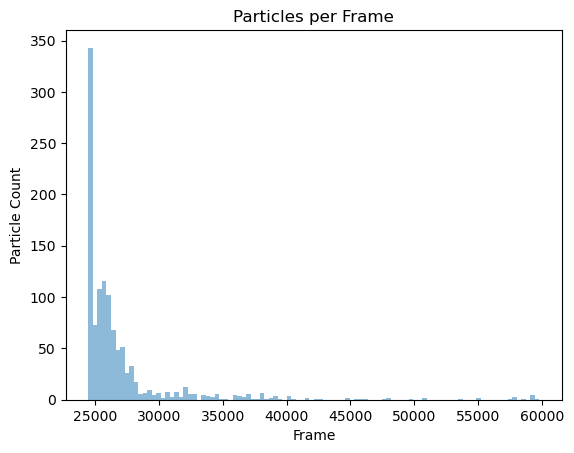

In [22]:
plt.hist(df['frame'], bins=100, alpha=0.5, label="data1")
plt.xlabel('Frame')
plt.ylabel('Particle Count')
plt.title('Particles per Frame')
plt.show()

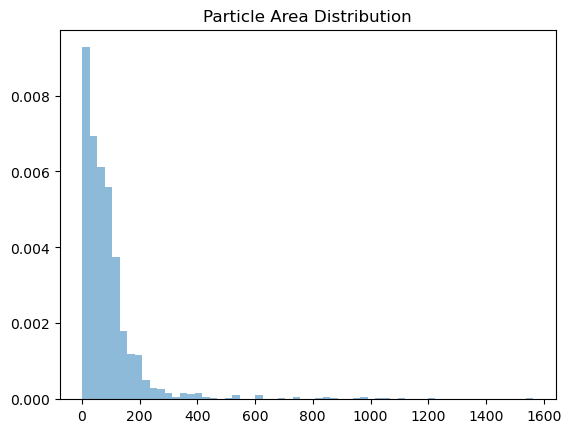

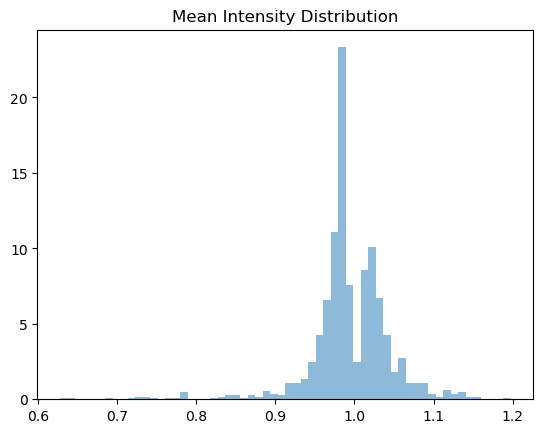

In [23]:
plt.hist(df['area'], bins=60, density=True, alpha=0.5)
plt.title('Particle Area Distribution')
plt.show()

plt.hist(df['mean_intensity'], bins=60, density=True, alpha=0.5)
plt.title('Mean Intensity Distribution')
plt.show()

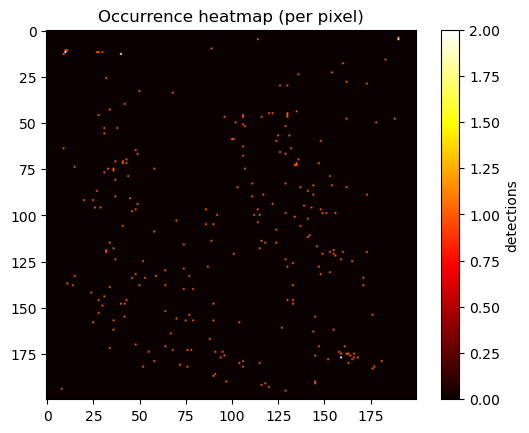

In [60]:
import matplotlib.pyplot as plt

H, W = 200, 200  # your movie size
# Optionally subset by frame range first:
# df_use = df_particles[(df_particles.frame >= 0) & (df_particles.frame < 1000)]
df_use = filtered_particles

# Round to nearest pixel and clip
xi = np.clip(np.rint(df_use["x"].to_numpy()).astype(int), 0, W-1)
yi = np.clip(np.rint(df_use["y"].to_numpy()).astype(int), 0, H-1)

# Count occurrences per pixel
heat = np.zeros((H, W), dtype=np.uint32)
np.add.at(heat, (yi, xi), 1)

# View
plt.figure()
plt.imshow(heat, origin="upper", cmap="hot")
plt.colorbar(label="detections")
plt.title("Occurrence heatmap (per pixel)")

# Save (16-bit or 32-bit)
tiff.imwrite("hotspots_perpixel.tiff", heat.astype(np.uint32))
